## 기계 결함 진단 (Machine Fault Diagnosis)

- 기계에서 발생하는 결함을 찾아내 **분류**하는 것
- **진동 신호**는 기계나 장비의 작동 상태와 관련된 다양한 정보를 제공하기 때문에 결함 진단에 많이 사용됨


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 라이브러리 및 데이터 불러오기

### 필요한 라이브러리 불러오기

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn import metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| Device:', device)


### 데이터 불러오기

데이터 셋: **Case Western Reserve University bearing dataset (CWRU)**

- 회전 기계의 베어링 손상 유무, 손상 위치 및 정도에 따른 기계의 진동 신호의 변화를 기록한 데이터셋

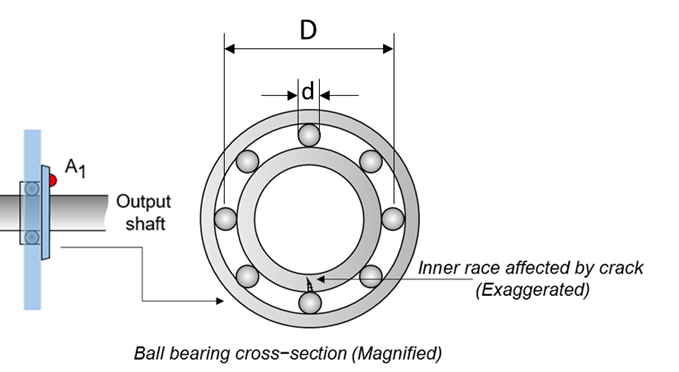

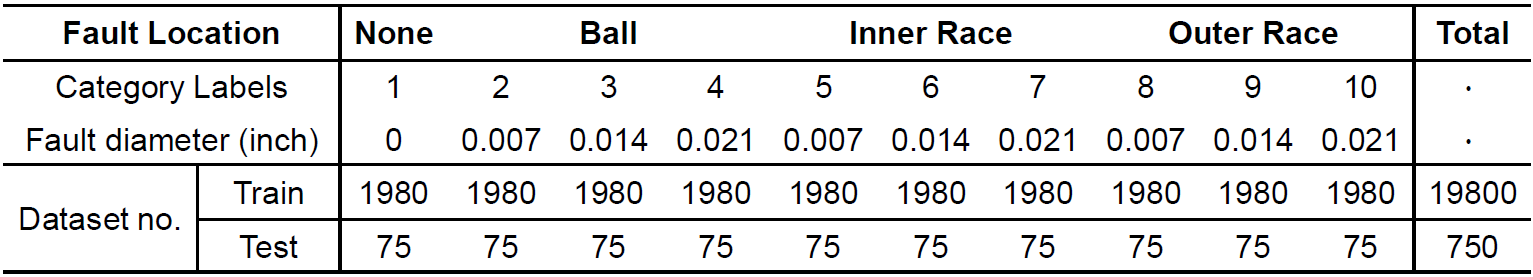

In [ ]:
import os 

path = 'C:\Users\Admin\OneDrive\바탕 화면\실습\7일차' #경로복사

x_train = np.load(path + '/Dataset/cwru/X_train.npy')
y_train = np.load(path + '/Dataset/cwru/y_train.npy')
x_test = np.load(path + '/Dataset/cwru/X_test.npy')
y_test = np.load(path + '/Dataset/cwru/y_test.npy')


In [ ]:
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

In [ ]:
x_train[0]

In [ ]:
y_train

In [ ]:
f, axes = plt.subplots(3,3,sharey='all')
f.set_size_inches((15,10))
for i in range(3):
    for j in range(3):
        axes[i,j].plot(x_train[np.where(y_train==3*i+j)][0])
        axes[i,j].set_title('class: {}'.format(3*i+j))
plt.show()

## 실습 : Dataset과 Dataloader 만들기

In [ ]:
x_train.shape, y_train.shape

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TSData(Dataset):
    def __init__(self, X, Y):
      # self.X = torch.tensor(X, dtype=torch.float32) ##
        self.X = torch.tensor(X, dtype=torch.float32).reshape(X.shape[0], -1, X.shape[1]) ##
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self): 
        return len(self.Y)
        #return Y[0].shape


    def __getitem__(self, idx):
         return self.X[idx], self.Y[idx]

In [ ]:
train_dataset = TSData(x_train, y_train)
test_dataset = TSData(x_test, y_test)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
for x,y in train_loader:
  break

print(x.shape, y.shape) ## (Batch, 1, 2048), (Batch, 1)

## 1D CNN


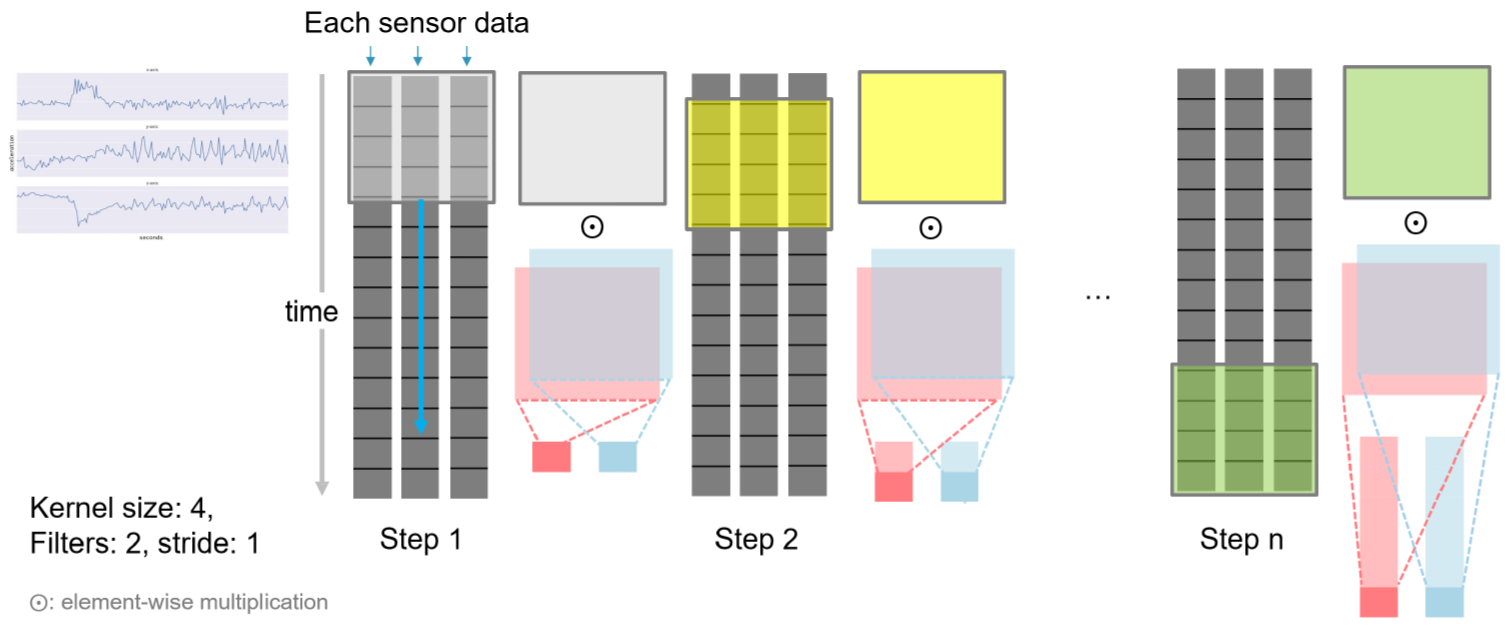

In [ ]:
layer = nn.Conv1d(
    in_channels = 1,
    out_channels = 16,
    kernel_size = 20,
    stride = 16
)

In [ ]:
layer(x).shape

### 모델 설계

In [ ]:
class CNN1D_Basic(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=20, stride=16),
            nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=3, stride=16),
            nn.ReLU(),
            nn.Flatten(),
            nn.LazyLinear(40),
            nn.Sigmoid(),
            nn.Linear(40, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def to_conv1d_input(x):
    # (N, T, 1) -> (N, 1, T)
    if x.ndim == 2:
        return torch.tensor(x, dtype=torch.float32).unsqueeze(1)
    return torch.tensor(x, dtype=torch.float32).permute(0, 2, 1)


model = CNN1D_Basic(num_classes=len(np.unique(y_train)))
print(model)


In [ ]:
model = CNN1D_Basic(num_classes=10)

### 모델 학습

In [ ]:
def fit_cnn(model, train_loader, test_loader, epochs=50, batch_size=64, val_ratio=0.2, patience=5, lr=1e-3):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val, wait = float('inf'), 0
    for epoch in range(1, epochs + 1):
        model.train()
        for (xb, yb) in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (xb, yb) in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(test_dataset)
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:02d} val_loss={val_loss:.4f}')
        if val_loss < best_val:
            best_val, wait = val_loss, 0
        else:
            wait += 1
            if wait >= patience:
                print('Early stopping')
                break


In [ ]:
fit_cnn(model,train_loader, test_loader, epochs=50, patience=5)


### 학습 결과

In [ ]:
model.eval()
with torch.no_grad():
  y_pred_list = [] 
  for x, y in test_loader:
    y_pred_test = model(x.to(device)).cpu().numpy()
    y_pred_list.append(y_pred_test)

In [ ]:
len(y_pred_list), y_pred_list[0].shape

In [ ]:
y_preds = np.concatenate(y_pred_list, axis=0)


In [ ]:
y_preds.shape

In [ ]:
y_preds[0]

In [ ]:
y_pred_test_classes = np.argmax(y_preds, axis=1)

In [ ]:
y_pred_test_classes

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix = confusion_matrix(y_test, y_pred_test_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.title('Confusion matrix', fontsize=16)
plt.show()

### 모델 고도화

In [ ]:
class CNN1D_Advanced(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=16, padding=32), nn.BatchNorm1d(16), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=3, stride=1, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=3, stride=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(100), nn.Sigmoid(),
            nn.Dropout(0.5),
            nn.Linear(100, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = CNN1D_Advanced(num_classes=len(np.unique(y_train)))
print(model)


In [ ]:
fit_cnn(model, x_train, y_train, epochs=10, patience=2)


In [ ]:
model.eval()
with torch.no_grad():
  y_pred_list = [] 
  for x, y in test_loader:
    y_pred_test = model(x.to(device)).cpu().numpy()
    y_pred_list.append(y_pred_test)

y_preds = np.concatenate(y_pred_list, axis=0)
y_pred_test_classes = np.argmax(y_preds, axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix = confusion_matrix(y_test, y_pred_test_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.title('Confusion matrix', fontsize=16)
plt.show()

**WDCNN**

Zhang, Wei, et al. "A new deep learning model for fault diagnosis with good anti-noise and domain adaptation ability on raw vibration signals." Sensors 17.2 (2017): 425.

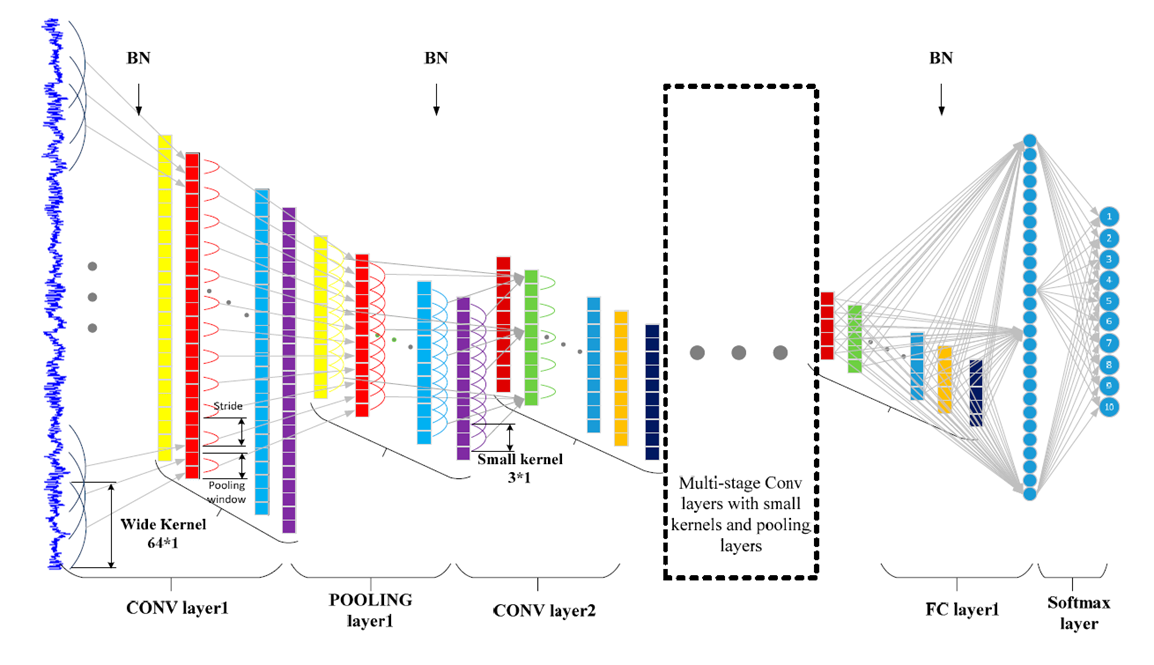